In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference

# Activamos el autoreload para que Jupyter detecte cambios en data_utils.py
%load_ext autoreload
%autoreload 2

# Importamos nuestro módulo común personalizado
from data_utils import load_and_clean_compas, obtener_preprocesador, evaluar_rendimiento, evaluar_equidad_multivariable

In [7]:
# Carga de datos 
X, y = load_and_clean_compas('./dataset/compas-scores-two-years.csv')

# División estratificada combinada (Target + Raza)
stratify_cols = y.astype(str) + X['race'].astype(str)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=stratify_cols
)

# Ajuste y transformación del preprocesador numérico/categórico
preprocessor = obtener_preprocesador()
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print("Estructura de las características de entrenamiento:", X_train.columns.tolist())

Estructura de las características de entrenamiento: ['sex', 'age', 'race', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'priors_count', 'c_charge_degree']


#### **Entrenamiento de modelos: Base y mitigado**

In [9]:
# 1. Modelo Baseline (Sesgado por el histórico)
print("Entrenando XGBoost base...")
xgb_base = XGBClassifier(random_state=42, n_estimators=100, max_depth=4)
xgb_base.fit(X_train_proc, y_train)

# 2. Modelo Curado (Mitigador con restricciones de Equalized Odds)
print("Entrenando mitigador de sesgo algorítmico...")
sensitive_train_race = X_train['race']

xgb_mitigado = ExponentiatedGradient(
    estimator=XGBClassifier(random_state=42, n_estimators=100, max_depth=4),  # <--- Corregido aquí
    constraints=EqualizedOdds(),
    eps=0.01
)
xgb_mitigado.fit(X_train_proc, y_train, sensitive_features=sensitive_train_race)

print("\n=== EVALUACIÓN DE RENDIMIENTO PREDICTIVO ===")
print("\n[Modelo Base]")
_ = evaluar_rendimiento(xgb_base, X_test_proc, y_test)

print("\n[Modelo Mitigado]")
_ = evaluar_rendimiento(xgb_mitigado, X_test_proc, y_test)

Entrenando XGBoost base...
Entrenando mitigador de sesgo algorítmico...

=== EVALUACIÓN DE RENDIMIENTO PREDICTIVO ===

[Modelo Base]
--- Rendimiento del Modelo ---
Accuracy: 0.6598
F1-Score: 0.5946
AUC-ROC:  0.7151

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.67      0.75      0.71      1009
           1       0.65      0.55      0.59       843

    accuracy                           0.66      1852
   macro avg       0.66      0.65      0.65      1852
weighted avg       0.66      0.66      0.66      1852


[Modelo Mitigado]
--- Rendimiento del Modelo ---
Accuracy: 0.6517
F1-Score: 0.5847
AUC-ROC:  No disponible para este mitigador (modelo estocástico).

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.66      0.75      0.70      1009
           1       0.64      0.54      0.58       843

    accuracy                           0.65      1852
   macro avg       0.65      0.64 

#### **Preparación forense multivariable**

In [10]:
# Creamos una copia local exclusivamente para estructurar las visualizaciones
X_test_audit = X_test.copy()

# Mapeo categórico temporal: Necesario para que MetricFrame pueda agrupar las métricas
def categorizar_edad_auditoria(edad):
    if edad < 25: return 'Menor de 25'
    elif edad <= 45: return '25 - 45'
    return 'Mayor de 45'

X_test_audit['age_group'] = X_test_audit['age'].apply(categorizar_edad_auditoria)

# Generación de variables interseccionales utilizando el nuevo grupo de edad
X_test_audit['race_sex'] = X_test_audit['race'].astype(str) + " / " + X_test_audit['sex'].astype(str)
X_test_audit['race_age'] = X_test_audit['race'].astype(str) + " / " + X_test_audit['age_group'].astype(str)

# Dimensiones finales libres de cualquier KeyError
dimensiones_a_auditar = ['race', 'sex', 'age_group', 'race_sex', 'race_age']

# Extraemos las predicciones finales de ambos estimadores
y_pred_base = xgb_base.predict(X_test_proc)
y_pred_mitigado = xgb_mitigado.predict(X_test_proc)

In [11]:
import pandas as pd
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference

gaps_globales = []

for dimension in dimensiones_a_auditar:
    print("\n" + "="*70)
    print(f" AUDITORÍA DE IMPACTO DISPAR: DIMENSIÓN [{dimension.upper()}]")
    print("="*70)
    
    mf_base = evaluar_equidad_multivariable(y_test, y_pred_base, X_test_audit[dimension])
    mf_mit = evaluar_equidad_multivariable(y_test, y_pred_mitigado, X_test_audit[dimension])
    
    print("\n[Desglose por Subgrupos - MODELO BASE]")
    display(mf_base.by_group.round(4))
    
    print("\n[Desglose por Subgrupos - MODELO MITIGADO]")
    display(mf_mit.by_group.round(4))
    
    gaps_globales.append({
        'Dimensión': dimension,
        'Demographic Parity Gap (Base)': demographic_parity_difference(y_test, y_pred_base, sensitive_features=X_test_audit[dimension]),
        'Demographic Parity Gap (Mitigado)': demographic_parity_difference(y_test, y_pred_mitigado, sensitive_features=X_test_audit[dimension]),
        'Equalized Odds Gap (Base)': equalized_odds_difference(y_test, y_pred_base, sensitive_features=X_test_audit[dimension]),
        'Equalized Odds Gap (Mitigado)': equalized_odds_difference(y_test, y_pred_mitigado, sensitive_features=X_test_audit[dimension])
    })

# Formateamos el DataFrame global resumen para tu manuscrito científico
df_resumen_gaps = pd.DataFrame(gaps_globales)
print("\n" + "="*70)
print(" RESUMEN GLOBAL DE DIFERENCIAS DE EQUIDAD (GAPS)")
print("="*70)
display(df_resumen_gaps.round(4))


 AUDITORÍA DE IMPACTO DISPAR: DIMENSIÓN [RACE]

[Desglose por Subgrupos - MODELO BASE]


c:\Users\Usuario\Universidad\A3\cuatri_2\AA\proyecto_final\AA_proyect\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Accuracy,Precision (PPV),TPR (Recall),FPR (Falsos Positivos),FNR (Falsos Negativos),Selection Rate
race,,,,,,
African-American,0.6555,0.6763,0.6546,0.3436,0.3454,0.5063
Asian,0.7778,0.5000,0.5000,0.1429,0.5000,0.2222
Caucasian,0.6609,0.6038,0.3887,0.1641,0.6113,0.2520
Hispanic,0.6797,0.5909,0.4561,0.1875,0.5439,0.2876
Native American,0.5000,0.0000,0.0000,0.0000,1.0000,0.0000
Other,0.6602,0.5417,0.3514,0.1667,0.6486,0.2330



[Desglose por Subgrupos - MODELO MITIGADO]


,Accuracy,Precision (PPV),TPR (Recall),FPR (Falsos Positivos),FNR (Falsos Negativos),Selection Rate
race,,,,,,
African-American,0.6481,0.7022,0.5683,0.2643,0.4317,0.4233
Asian,1.0000,1.0000,1.0000,0.0000,0.0000,0.2222
Caucasian,0.6561,0.5721,0.4818,0.2318,0.5182,0.3296
Hispanic,0.6732,0.5538,0.6316,0.3021,0.3684,0.4248
Native American,0.7500,1.0000,0.5000,0.0000,0.5000,0.2500
Other,0.6699,0.5429,0.5135,0.2424,0.4865,0.3398


...

,Accuracy,Precision (PPV),TPR (Recall),FPR (Falsos Positivos),FNR (Falsos Negativos),Selection Rate
race_age,,,,,,
African-American / 25 - 45,0.6695,0.6688,0.7023,0.3649,0.2977,0.5377
African-American / Mayor de 45,0.6489,0.6571,0.4035,0.1622,0.5965,0.2672
African-American / Menor de 25,0.6245,0.6992,0.6549,0.4211,0.3451,0.5612
Asian / 25 - 45,0.8000,0.5000,1.0000,0.2500,0.0000,0.4000
Asian / Mayor de 45,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Asian / Menor de 25,0.5000,0.0000,0.0000,0.0000,1.0000,0.0000
Caucasian / 25 - 45,0.6276,0.5876,0.3958,0.2030,0.6042,0.2845
Caucasian / Mayor de 45,0.7444,0.5333,0.1702,0.0526,0.8298,0.0833
Caucasian / Menor de 25,0.6273,0.6596,0.5536,0.2963,0.4464,0.4273



[Desglose por Subgrupos - MODELO MITIGADO]


,Accuracy,Precision (PPV),TPR (Recall),FPR (Falsos Positivos),FNR (Falsos Negativos),Selection Rate
race_age,,,,,,
African-American / 25 - 45,0.6678,0.7043,0.6054,0.2667,0.3946,0.4401
African-American / Mayor de 45,0.6336,0.6552,0.3333,0.1351,0.6667,0.2214
African-American / Menor de 25,0.6076,0.7094,0.5845,0.3579,0.4155,0.4937
Asian / 25 - 45,1.0000,1.0000,1.0000,0.0000,0.0000,0.2000
Asian / Mayor de 45,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Asian / Menor de 25,1.0000,1.0000,1.0000,0.0000,0.0000,0.5000
Caucasian / 25 - 45,0.6158,0.5512,0.4861,0.2893,0.5139,0.3724
Caucasian / Mayor de 45,0.7444,0.5200,0.2766,0.0902,0.7234,0.1389
Caucasian / Menor de 25,0.6364,0.6429,0.6429,0.3704,0.3571,0.5091



 RESUMEN GLOBAL DE DIFERENCIAS DE EQUIDAD (GAPS)


,Dimensión,Demographic Parity Gap (Base),Demographic Parity Gap (Mitigado),Equalized Odds Gap (Base),Equalized Odds Gap (Mitigado)
0,race,0.5063,0.2026,0.6546,0.5182
1,sex,0.1702,0.1549,0.1526,0.1600
2,age_group,0.3672,0.3672,0.3429,0.3516
3,race_sex,1.0000,1.0000,1.0000,1.0000
4,race_age,0.5612,1.0000,1.0000,1.0000


c:\Users\Usuario\Universidad\A3\cuatri_2\AA\proyecto_final\AA_proyect\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


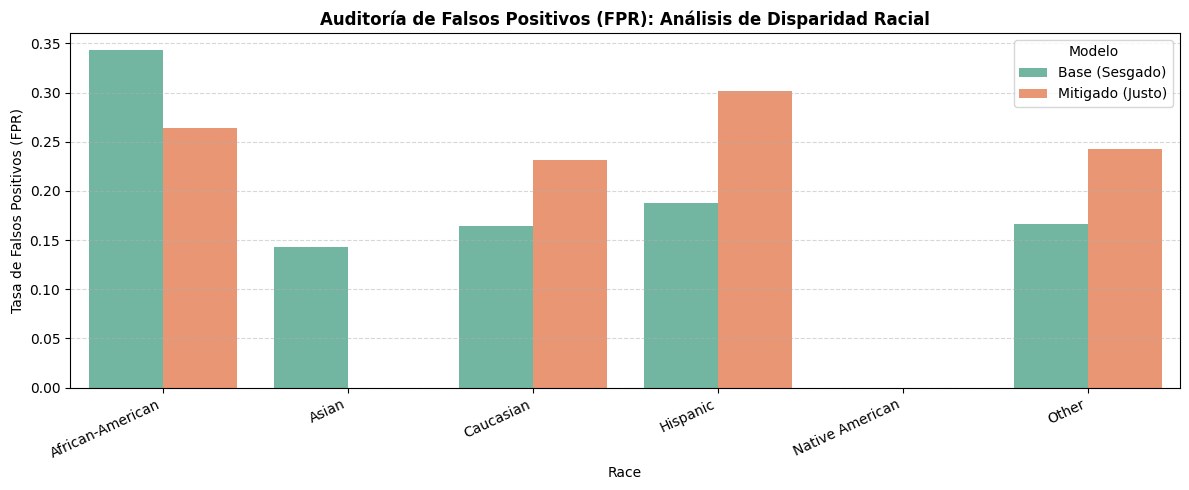

c:\Users\Usuario\Universidad\A3\cuatri_2\AA\proyecto_final\AA_proyect\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuario\Universidad\A3\cuatri_2\AA\proyecto_final\AA_proyect\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuario\Universidad\A3\cuatri_2\AA\proyecto_final\AA_proyect\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control

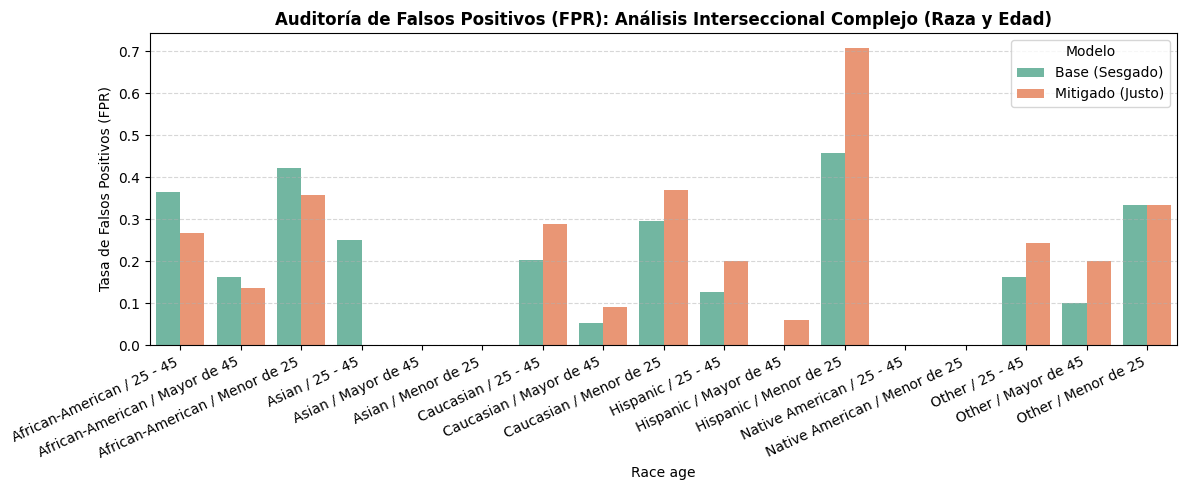

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

def graficar_comparativa_fpr(columna, titulo):
    mf_base = evaluar_equidad_multivariable(y_test, y_pred_base, X_test_audit[columna])
    mf_mit = evaluar_equidad_multivariable(y_test, y_pred_mitigado, X_test_audit[columna])
    
    df_plot = pd.DataFrame({
        'FPR': list(mf_base.by_group['FPR (Falsos Positivos)']) + list(mf_mit.by_group['FPR (Falsos Positivos)']),
        'Subgrupo': list(mf_base.by_group.index) + list(mf_mit.by_group.index),
        'Modelo': ['Base (Sesgado)'] * len(mf_base.by_group) + ['Mitigado (Justo)'] * len(mf_mit.by_group)
    })
    
    plt.figure(figsize=(12, 5))
    sns.barplot(data=df_plot, x='Subgrupo', y='FPR', hue='Modelo', palette='Set2')
    plt.title(f'Auditoría de Falsos Positivos (FPR): {titulo}', fontsize=12, fontweight='bold')
    plt.ylabel('Tasa de Falsos Positivos (FPR)')
    plt.xlabel(columna.replace('_', ' ').capitalize())
    plt.xticks(rotation=25, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Lanzamos las dos gráficas analíticas principales
graficar_comparativa_fpr('race', 'Análisis de Disparidad Racial')
graficar_comparativa_fpr('race_age', 'Análisis Interseccional Complejo (Raza y Edad)')